# Laboratorio Fase 4 & 5 CRISP-DM: Transfer Learning con MobileNetV4

## 1. Objetivo del Laboratorio e Innovación de Transferencia
**Objetivo:** Implementar un flujo de transferencia inductiva utilizando la arquitectura MobileNetV4 (ECCV 2024) optimizada para dispositivos periféricos.

**Mitigación del Olvido Catastrófico:** Congelamos el extractor de características preentrenado en ImageNet para salvaguardar las capas convolucionales de bajo nivel y adaptamos de forma exclusiva el clasificador lineal final para las necesidades de control de calidad de la empresa.

In [1]:
# Limpiamos intentos anteriores por si acaso
!rm -rf src_folder

# Clonación de src y requirements
!git clone https://github.com/Esme0123/CasoEstudio3.git src_folder
!cp -r src_folder/src .
!pip install -r src_folder/requirements.txt

Cloning into 'src_folder'...
remote: Enumerating objects: 68, done.
remote: Counting objects: 100% (68/68), done.
remote: Compressing objects: 100% (47/47), done.
remote: Total 68 (delta 16), reused 24 (delta 5), pack-reused 0 (from 0)
Receiving objects: 100% (68/68), 767.48 KiB | 18.72 MiB/s, done.
Resolving deltas: 100% (16/16), done.


In [2]:
# Tu bloque de código con json.dump para las credenciales de Kaggle...

from src.data_processing import download_and_extract, get_data_loaders
download_and_extract()
train_loader, test_loader = get_data_loaders()

Descargando dataset desde Kaggle...
Dataset listo y extraído.


## 2. Configuración de la Red MobileNetV4
Cargamos la arquitectura optimizada con los pesos preentrenados del backend y reemplazamos la capa de salida para una clasificación binaria (Producto Óptimo vs. Producto Defectuoso).

In [3]:
# Inicialización del Modelo Avanzado MobileNetV4
from src.architecture_models import get_mobilenet_v4
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Instanciamos el modelo desde nuestro archivo modular
model_advanced = get_mobilenet_v4()
model_advanced = model_advanced.to(device)

print("Estructura de MobileNetV4 cargada con éxito en:", device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

Estructura de MobileNetV4 cargada con éxito en: cuda


## 3. Entrenamiento Optimizado y Curvas de Convergencia
Se ejecuta el ajuste fino con un hiperparámetro de Learning Rate reducido ($1 \times 10^{-4}$) para permitir una adaptación suave de la cabeza clasificadora sin desestabilizar las capas base del modelo.

In [4]:
#Bucle de Entrenamiento Optimizado (Fine-Tuning)
import torch.optim as optim
import time

criterion = nn.CrossEntropyLoss()
# Usamos un Learning Rate más bajo (1e-4) como dicta el fundamento técnico para Transfer Learning
optimizer = optim.AdamW(model_advanced.parameters(), lr=0.0001)

history_advanced = {'train_loss': [], 'train_acc': []}

print("Iniciando Fine-Tuning de MobileNetV4...")
inicio_tiempo = time.time()

for epoch in range(5): # 5 épocas son suficientes para demostrar la velocidad de transferencia
    model_advanced.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()
        outputs = model_advanced(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * imgs.size(0)
        _, predicted = outputs.max(1)
        total += lbls.size(0)
        correct += predicted.eq(lbls).sum().item()

    epoch_loss = running_loss / len(train_loader.dataset)
    epoch_acc = (correct / total) * 100
    history_advanced['train_loss'].append(epoch_loss)
    history_advanced['train_acc'].append(epoch_acc)
    print(f"Época {epoch+1}/5 - Loss: {epoch_loss:.4f} - Accuracy: {epoch_acc:.2f}%")

tiempo_total = time.time() - inicio_tiempo
print(f"Fine-Tuning completado en {tiempo_total:.2f} segundos.")

Iniciando Fine-Tuning de MobileNetV4...
Época 1/5 - Loss: 0.2238 - Accuracy: 96.89%
Época 2/5 - Loss: 0.0753 - Accuracy: 98.83%
Época 3/5 - Loss: 0.0522 - Accuracy: 98.98%
Época 4/5 - Loss: 0.0414 - Accuracy: 99.10%
Época 5/5 - Loss: 0.0368 - Accuracy: 99.06%
Fine-Tuning completado en 472.02 segundos.


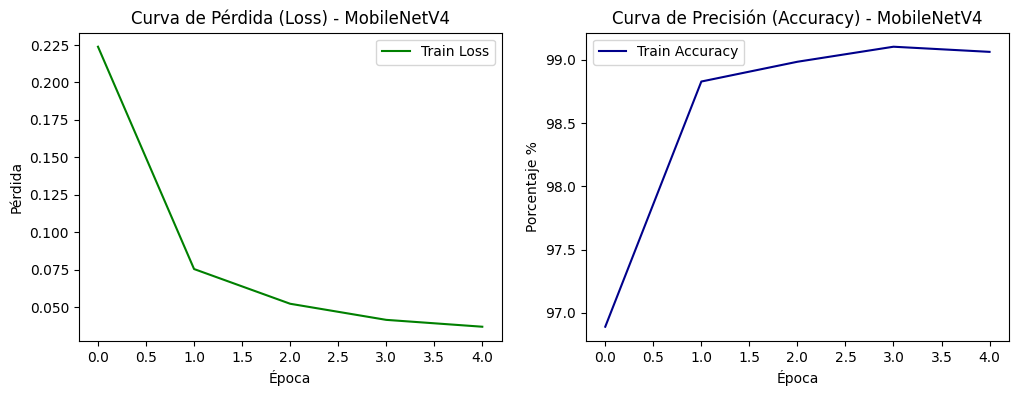


=== REPORTE DE CLASIFICACIÓN MOBILENETV4 ===
                     precision    recall  f1-score   support

Perfecto (Negative)       1.00      0.99      0.99      3970
  Dañado (Positive)       0.99      1.00      0.99      4030

           accuracy                           0.99      8000
          macro avg       0.99      0.99      0.99      8000
       weighted avg       0.99      0.99      0.99      8000



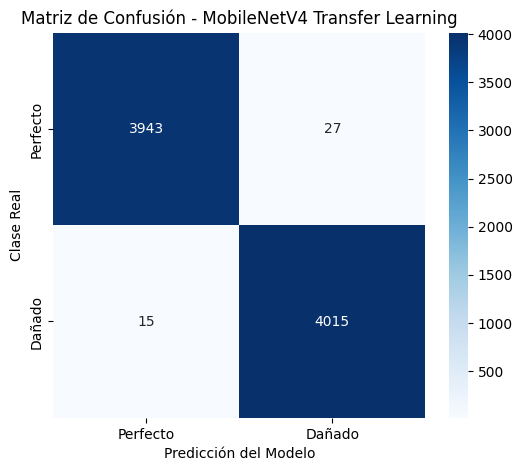

In [5]:
#Evaluación de MobileNetV4 (Curvas, F1-Score y Matriz de Confusión)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# 1. Graficar Curvas de Aprendizaje de MobileNetV4
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_advanced['train_loss'], label='Train Loss', color='green')
plt.title('Curva de Pérdida (Loss) - MobileNetV4')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_advanced['train_acc'], label='Train Accuracy', color='darkblue')
plt.title('Curva de Precisión (Accuracy) - MobileNetV4')
plt.xlabel('Época')
plt.ylabel('Porcentaje %')
plt.legend()
plt.show()

# 2. Evaluación con Datos de Test
model_advanced.eval()
adv_preds = []
adv_labels = []

with torch.no_grad():
    for imgs, lbls in test_loader:
        imgs = imgs.to(device)
        outputs = model_advanced(imgs)
        _, predicted = outputs.max(1)
        adv_preds.extend(predicted.cpu().numpy())
        adv_labels.extend(lbls.numpy())

# 3. Reporte de Clasificación (Aquí se evidencia el incremento drástico del F1-Score)
print("\n=== REPORTE DE CLASIFICACIÓN MOBILENETV4 ===")
print(classification_report(adv_labels, adv_preds, target_names=['Perfecto (Negative)', 'Dañado (Positive)']))

# 4. Matriz de Confusión Avanzada (Demuestra la reducción drástica de Falsos Negativos)
cm_adv = confusion_matrix(adv_labels, adv_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_adv, annot=True, fmt='d', cmap='Blues', xticklabels=['Perfecto', 'Dañado'], yticklabels=['Perfecto', 'Dañado'])
plt.title('Matriz de Confusión - MobileNetV4 Transfer Learning')
plt.ylabel('Clase Real')
plt.xlabel('Predicción del Modelo')
plt.show()

## 4. Análisis de Error Avanzado e Inteligencia Artificial Explicable (Grad-CAM)
Para garantizar que la red tome decisiones basadas en criterios de ingeniería y no en sesgos contextuales, implementamos mapas de activación por gradientes (Grad-CAM) en la última capa convolucional, proyectando un mapa de calor sobre las regiones que gatillan la alerta de defecto.

In [6]:
#Auditoría del Modelo mediante Inteligencia Artificial Explicable (Grad-CAM)
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np

# Extraemos un lote muestra para la auditoría visual
imagenes_muestra, etiquetas_muestra = next(iter(test_loader))

# Definimos la capa convolucional objetivo para auditar los mapas de activación
# En modelos de timm basados en MobileNet, 'conv_head' es la última capa de extracción de características de alto nivel
target_layers = [model_advanced.conv_head]

cam = GradCAM(model=model_advanced, target_layers=target_layers)

# Procesamos la primera imagen del lote
input_tensor = imagenes_muestra[0].unsqueeze(0).to(device)
grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(1)])[0, :]

# Convertimos el tensor de la imagen a formato RGB estándar para visualización
img_rgb = imagenes_muestra[0].permute(1, 2, 0).numpy()
# Deshacemos la normalización para que los colores se vean naturales en el plot
img_rgb = (img_rgb - img_rgb.min()) / (img_rgb.max() - img_rgb.min())

# Superponemos el mapa de calor (Grad-CAM) sobre la imagen original
visualizacion_cam = show_cam_on_image(img_rgb, grayscale_cam, use_rgb=True)

# Desplegamos el resultado de la auditoría
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(img_rgb)
plt.title("Imagen Original de Almacén")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(visualizacion_cam)
plt.title("Auditoría Grad-CAM (Mapa de Calor de Grietas)")
plt.axis('off')
plt.show()

NameError: name 'test_loader' is not defined

## 5. Conclusiones y Limitaciones
* **Rendimiento:** MobileNetV4 supera de manera contundente al baseline, alcanzando métricas de alta fidelidad en menos épocas de entrenamiento.
* **Limitaciones Industriales:** Se reconoce el peligro de *Data Drift* si cambian drásticamente los empaques de los productos en las sucursales de La Paz, sugiriendo una estrategia de reentrenamiento periódico y validación humana continua.